# Introducción a NumPy, Pandas y Matplotlib con el Dataset Iris

En este notebook exploraremos el famoso conjunto de datos **Iris**. El objetivo principal es demostrar:
1. Cómo **descargar datos** utilizando un formato estándar y generalizable desde internet.
2. Cómo utilizar **Pandas** para la carga, exploración y manipulación inicial de datos.
3. Cómo utilizar **NumPy** para extraer arreglos y realizar operaciones numéricas.
4. Cómo utilizar **Matplotlib** para visualizar distribuciones y relaciones entre variables.

## ¿Qué es el Dataset Iris?

El **Dataset Iris** es probablemente el conjunto de datos de reconocimiento de patrones más conocido en la literatura de Machine Learning. Fue introducido por el estadístico y biólogo británico **Ronald Fisher** en su artículo de 1936, *"The use of multiple measurements in taxonomic problems"*.

Contiene 150 muestras de flores de la planta Iris, divididas equitativamente en 3 especies (50 muestras por cada una):
- *Iris setosa*
- *Iris virginica*
- *Iris versicolor*

Para cada muestra floral se midieron 4 características (en centímetros):
1. Largo del sépalo (sepal length)
2. Ancho del sépalo (sepal width)
3. Largo del pétalo (petal length)
4. Ancho del pétalo (petal width)

**Importancia histórica:** Este dataset es considerado el "Hola Mundo" del Machine Learning y la Ciencia de Datos. Es pequeño, está balanceado, es fácil de entender y es un entorno controlado excelente para probar e introducir nuevos algoritmos de clasificación estadística.

## Herramientas Clave en el Ecosistema Python para Machine Learning

Antes de comenzar a explorar los datos, es importante consolidar qué son y por qué importan las librerías que vamos a importar. Estas tres herramientas forman la columna vertebral de casi cualquier proyecto moderno de análisis de datos y ML modular en Python:

### 1. NumPy (Numerical Python)
Es la biblioteca fundacional para la computación científica en Python.
- **¿Qué hace?** Proporciona rutinas nativas para procesamiento de arreglos y matrices multidimensionales (el objeto `ndarray`), con una vasta colección de unciones matemáticas de alto nivel para aplicarse sobre ellos.
- **En la práctica de ML:** Todo algoritmo de modelos (como las redes neuronales o los modelos lineales) espera que sus entradas de datos pasen por arreglos NumPy. Como NumPy delega ciclos al lenguaje C que opera en back-end, la velocidad y uso de memoria supera estrepitosamente a las litas estándar de Python.

### 2. Pandas
Considerada la herramienta *defacto* de la industria para manipular información en formatos tabulares o relacionales.
- **¿Qué hace?** Nos ofrece unas estructuras de datos intuitivas llamadas **Series** (representarán tus columnas) y **DataFrames** (tablas bidimensionales, asimilables a una hoja de Excel o tablas relacionales integradas).
- **En la práctica de ML:** En la crucial ventana de preparación de datos (*Data Preprocessing*), utilizarás Pandas rigurosamente: lo emplearás para recolectar las fuentes originales de información, escudriñar los valores nulos, fusionar tablas, encodificar categorizaciones de texto a dígitos y para dejar consolidada de forma limpia la matriz de Machine Learning definitiva para inyectarse al modelo.

### 3. Matplotlib
La principal base visual integrativa en 2D.
- **¿Qué hace?** Mapea variables en el lienzo. Desde proyecciones de histogramas rápidos hasta complejos gráficos de dispersión con variables cruzadas y sombreados.
- **En la práctica de ML:** Durante la etapa de **Análisis Exploratorio de Datos (EDA)** te brinda las "gafas analíticas" oportunas de tus registros. Te ayuda visualmente a certificar separaciones de clase por dispersión y verificar patrones sesgados de datos antes de apostar recursos lógicos a entrenamientos inútiles.

---

> 💡 **Información Complementaria para Proyectos Cotidianos:**
>
> 1. **El 80% del trabajo está en los Datos:** Si bien los algoritmos de inteligencia artificial pueden sentirse como la novedad de moda, habitúate a internalizar que un Data Scientist o ML Engineer en el ecosistema real de trabajo **gasta del 70% al 80% de su tiempo únicamente usando Pandas** para domar, cruzar, rectificar y transformar datos problemáticos (*Data Wrangling*).
>
> 2. **Librerías Hermandas Inminentes:** Una vez que estos datos son transformados mediante la tríada `Pandas -> Numpy -> Matplotlib`, los arrays tabulados y normalizados finalmente se depositan de manera universal a módulos tales como `scikit-learn` para ajustar hiperparámetros del Modelo Clásico.

In [ ]:
#!pip install pandas
#!pip install numpy
#!pip install matplotlib

In [1]:
# Importación de las librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Comando mágico para asegurar que los gráficos de Matplotlib se muestren incrustados en el notebook
%matplotlib inline

## 1. Carga de Datos Estándar (Pandas)

La manera más estandarizada y generalizable de obtener un dataset es leyendo un archivo CSV o de texto plano directamente desde un enlace (URL). Esto lo usaremos mucho al trabajar con datos de diferentes reposos (GitHub, UCI, repositorios gubernamentales, etc.).

A continuación, utilizaremos el repositorio público oficial *UCI Machine Learning Repository* y la función `read_csv` de Pandas.

In [2]:
# Definimos la URL directa al archivo de texto plano (formato CSV o datos tabulados similares)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Como el archivo original no contiene los nombres de las columnas, los definimos manualmente
columnas = ['largo_sepalo', 'ancho_sepalo', 'largo_petalo', 'ancho_petalo', 'especie']

# Cargamos los datos tabulados directamente desde la web hacia un DataFrame de Pandas
df = pd.read_csv(url, names=columnas)

# Mostramos las primeras 5 filas para verificar que la descarga se completó correctamente
df.head()

,largo_sepalo,ancho_sepalo,largo_petalo,ancho_petalo,especie
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.shape

(150, 5)

### Exploración Inicial Rápida
Es buena práctica revisar el tipo de datos y si existen valores nulos antes de comenzar a trabajar.

In [3]:
# Muestra información general sobre los tipos de columnas y la existencia de valores nulos (NaN)
print("---- Información General ----")
df.info()

print("\n---- Estadísticas Descriptivas ----")
# Proporciona estadísticas útiles (media, desviación estándar, min, max, cuartiles)
df.describe()

---- Información General ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   largo_sepalo  150 non-null    float64
 1   ancho_sepalo  150 non-null    float64
 2   largo_petalo  150 non-null    float64
 3   ancho_petalo  150 non-null    float64
 4   especie       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

---- Estadísticas Descriptivas ----


,largo_sepalo,ancho_sepalo,largo_petalo,ancho_petalo
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Relación y Operaciones con NumPy

Los DataFrames de Pandas utilizan matrices de NumPy como su base interna. A veces necesitamos extraer directamente estos arreglos multidimensionales (`ndarray`) para realizar operaciones más rápidas de bajo nivel o para preparar datos en machine learning.

In [4]:
# Extraemos una columna como un arreglo numérico unidimensional (NumPy array)
largo_sepalo_array = df['largo_sepalo'].values

print(f"Tipo del objeto extraído: {type(largo_sepalo_array)}")
print(f"Forma (shape) del arreglo: {largo_sepalo_array.shape}\n")

# Uso de funciones aritméticas de NumPy para estadísticas rápidas
media_numpy = np.mean(largo_sepalo_array)
desviacion_numpy = np.std(largo_sepalo_array)

print(f"Media del largo del sépalo calculada con NumPy: {media_numpy:.2f} cm")
print(f"Desviación estándar calculada con NumPy: {desviacion_numpy:.2f} cm\n")

# Operaciones matemáticas vectorizadas:
# Multiplicar todo el arreglo simultáneamente (ej, convertir cm a milímetros)
largo_sepalo_mm = largo_sepalo_array * 10
print(f"Primeros 5 valores en cm: {largo_sepalo_array[:5]}")
print(f"Primeros 5 correspondientes en mm: {largo_sepalo_mm[:5]}")

Tipo del objeto extraído: <class 'numpy.ndarray'>
Forma (shape) del arreglo: (150,)

Media del largo del sépalo calculada con NumPy: 5.84 cm
Desviación estándar calculada con NumPy: 0.83 cm

Primeros 5 valores en cm: [5.1 4.9 4.7 4.6 5. ]
Primeros 5 correspondientes en mm: [51. 49. 47. 46. 50.]


## 3. Visualizaciones con Matplotlib

Para entender realmente los datos, es vital visualizarlos. A continuación, utilizaremos Matplotlib para crear un par de gráficos que nos demuestren la distribución y la estructura subyacente de este dataset.

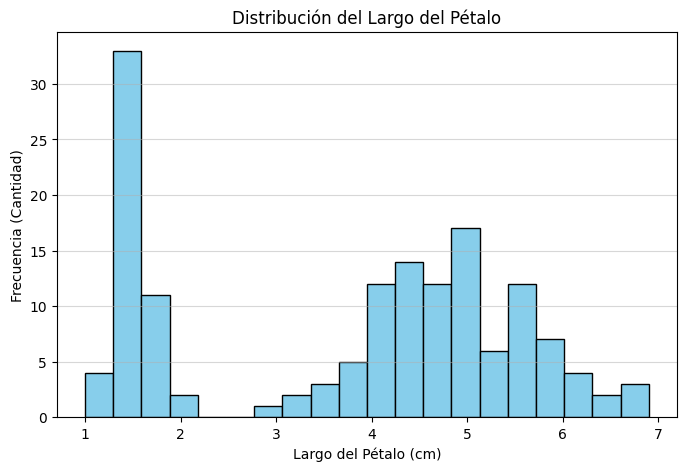

In [5]:
### Gráfico de Histograma (Distribución de una variable)
# Creamos una figura para definir el tamaño visible del gráfico
plt.figure(figsize=(8, 5))

# Utilizamos la función hist para crear el histograma sobre la columna 'largo_petalo'
plt.hist(df['largo_petalo'], bins=20, color='skyblue', edgecolor='black')

# Añadimos características estándar de presentación (título y etiquetas)
plt.title('Distribución del Largo del Pétalo')
plt.xlabel('Largo del Pétalo (cm)')
plt.ylabel('Frecuencia (Cantidad)')
plt.grid(axis='y', alpha=0.5)

# Mostramos el lienzo en pantalla
plt.show()

### Gráfico de Dispersión (Scatter Plot)
Un gráfico de dispersión bidimensional nos ayudará a entender cómo se diferencian las especies basado en dos variables simples.

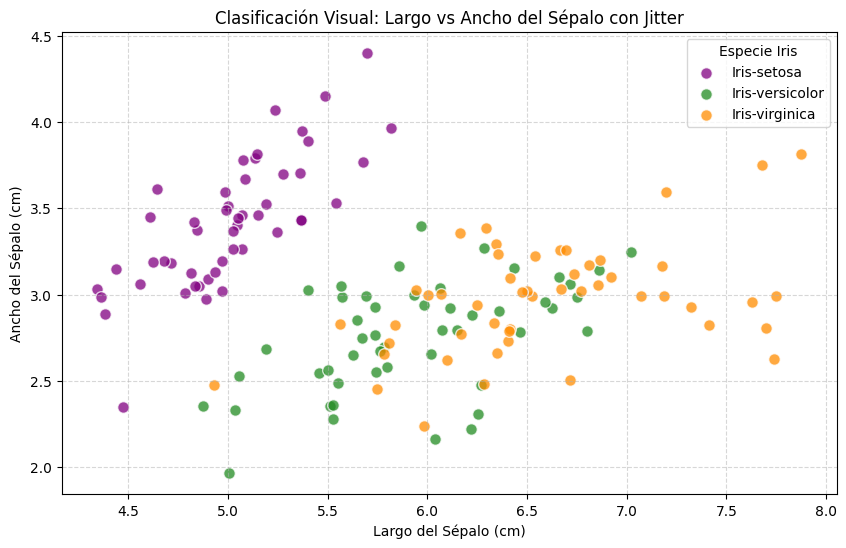

In [7]:
plt.figure(figsize=(10, 6))

# Obtenemos el listado de especies únicas
especies = df['especie'].unique()
colores = ['purple', 'forestgreen', 'darkorange']

# Definir la fuerza del jitter
jitter_strength = 0.05

# Iteramos por cada especie asignándole un color distinto al subconjunto de puntos
for especie, color in zip(especies, colores):
    # Extraemos solo las filas que corresponden a la especie actual
    subset = df[df['especie'] == especie]

    # Aplicar jitter a las columnas de interés
    jittered_largo_sepalo = subset['largo_sepalo'] + np.random.uniform(-jitter_strength, jitter_strength, len(subset))
    jittered_ancho_sepalo = subset['ancho_sepalo'] + np.random.uniform(-jitter_strength, jitter_strength, len(subset))

    # Creamos un diagrama de dispersión para la clase mapeada
    plt.scatter(
        x=jittered_largo_sepalo,
        y=jittered_ancho_sepalo,
        c=color,
        label=especie,
        alpha=0.75,
        edgecolors='white',
        s=70 # tamaño de la esfera
    )

plt.title('Clasificación Visual: Largo vs Ancho del Sépalo con Jitter')
plt.xlabel('Largo del Sépalo (cm)')
plt.ylabel('Ancho del Sépalo (cm)')
plt.legend(title='Especie Iris', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Scatterplot Matrix (Matriz de Gráficos de Dispersión)

Para obtener una visión general de las relaciones entre todas las variables numéricas del dataset, podemos usar una matriz de gráficos de dispersión. Esto nos ayuda a identificar patrones y separaciones entre las especies para cada par de características.

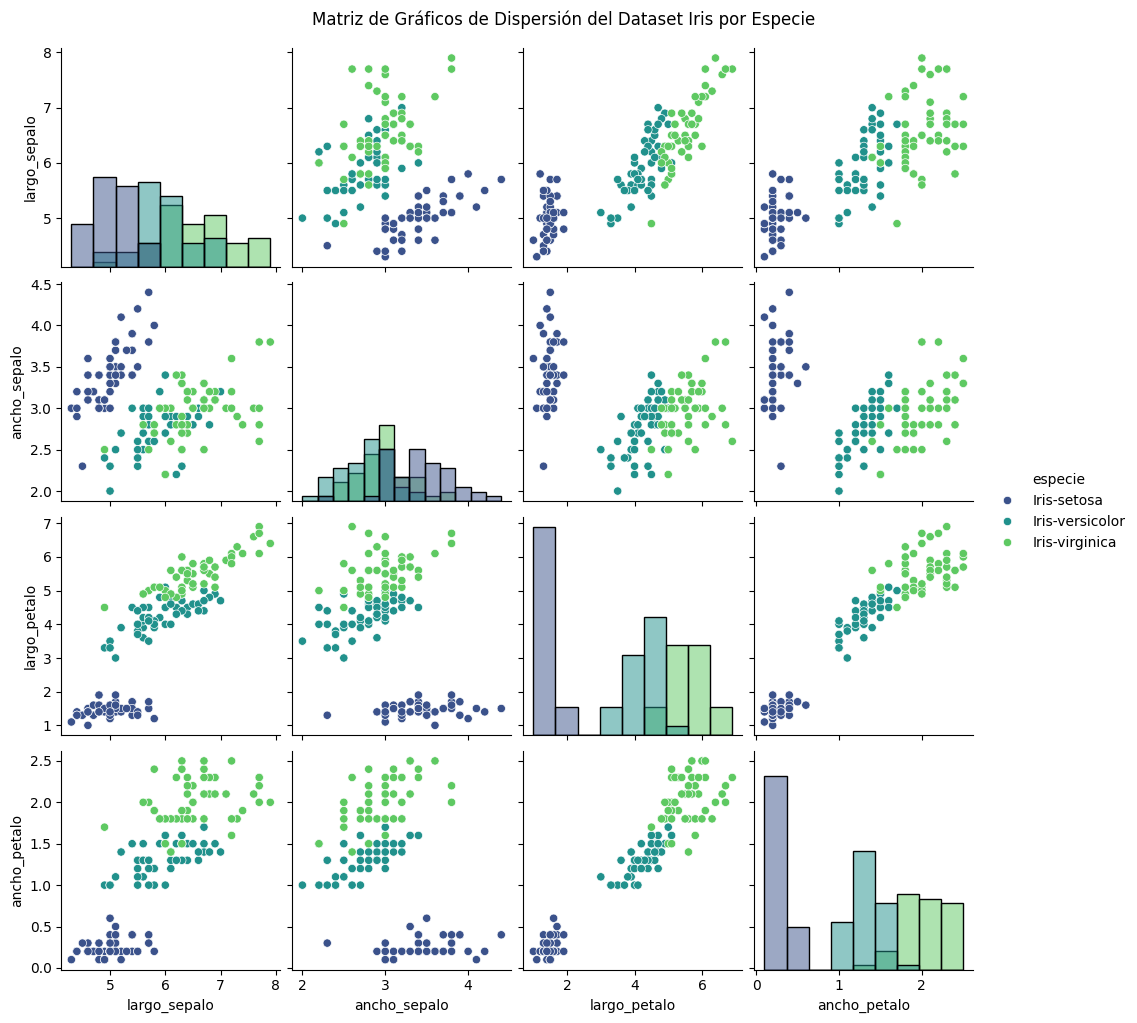

In [8]:
import seaborn as sns

# Crear la matriz de gráficos de dispersión
# 'hue' colorea los puntos según la columna 'especie'
# 'diag_kind' define el tipo de gráfico en la diagonal (histograma o kde)
sns.pairplot(df, hue='especie', diag_kind='hist', palette='viridis')

plt.suptitle('Matriz de Gráficos de Dispersión del Dataset Iris por Especie', y=1.02) # Añadir título general
plt.show()

## Conclusiones Finales

En resumen, hemos abarcado las tres capas fundamentales del análisis de datos moderno interactivo utilizando ecosistemas Python:
- Adquisición directa de la capa de datos subyacentes con lectura online estandarizada (**Pandas**).
- Acceso matemático granular al conjunto de arreglos para cómputo ágil (**NumPy**).
- Renderizado efectivo de comportamientos agrupados subyacentes y sus propiedades probabilísticas en 2D (**Matplotlib**).

## Actividad Práctica: Exploración del Dataset MPG

**Objetivo:** Aplicar las herramientas de NumPy, Pandas y Matplotlib (y Seaborn) para realizar un análisis exploratorio básico sobre un nuevo conjunto de datos: el **Dataset MPG (Miles Per Gallon)**.

Este dataset contiene información sobre el consumo de combustible de diferentes modelos de automóviles, junto con otras características como cilindros, desplazamiento, potencia, peso, aceleración, año del modelo y origen.

**Instrucciones:**

1.  **Investigación y Descarga del Dataset MPG:**
    *   Busca en internet el "MPG dataset UCI" o "Auto MPG dataset". Es comúnmente alojado en el repositorio UCI Machine Learning o distribuido por otras fuentes conocidas.
    *   Identifica la URL directa a la versión de texto plano o CSV del dataset. Presta atención si el archivo tiene encabezados o si necesitarás definirlos manualmente (como hicimos con el dataset Iris).
    *   Utiliza `pandas.read_csv()` para cargar el dataset directamente desde la URL en un DataFrame de Pandas.

2.  **Exploración Inicial del DataFrame (Pandas):**
    *   Muestra las primeras 5 filas del DataFrame (`.head()`) para verificar la carga.
    *   Obtén la información general del DataFrame (`.info()`) para conocer los tipos de datos y la presencia de valores nulos.
    *   Calcula y muestra estadísticas descriptivas básicas de las columnas numéricas (`.describe()`). Identifica cualquier valor atípico o rango inesperado.
    *   **Manejo de Datos Faltantes (si los hay):** Si encuentras valores nulos, decide cómo manejarlos. Por simplicidad para esta actividad, puedes optar por eliminarlos (`.dropna()`) o rellenarlos con la media (`.fillna(df.mean())`) si son pocos.

3.  **Análisis Numérico con NumPy (opcional pero recomendado):**
    *   Elige una columna numérica de interés (por ejemplo, 'horsepower' o 'weight').
    *   Extrae esta columna como un arreglo NumPy (`.values`).
    *   Utiliza funciones de NumPy (e.g., `np.mean()`, `np.std()`, `np.max()`, `np.min()`) para calcular algunas estadísticas rápidas sobre este arreglo.

4.  **Visualización con Matplotlib: Scatterplot:**
    *   Crea un gráfico de dispersión (`plt.scatter()`) para visualizar la relación entre dos variables numéricas que creas que podrían estar relacionadas (por ejemplo, 'horsepower' vs 'mpg' o 'weight' vs 'mpg').
    *   Asegúrate de:
        *   Asignar etiquetas claras a los ejes X e Y (`plt.xlabel()`, `plt.ylabel()`).
        *   Dar un título descriptivo al gráfico (`plt.title()`).
        *   Añadir una cuadrícula (`plt.grid()`).
        *   Puedes intentar colorear los puntos según una variable categórica si la identificas en el dataset (por ejemplo, 'origin' si está presente).

5.  **Visualización Avanzada con Seaborn: Scatterplot Matrix:**
    *   Utiliza `seaborn.pairplot()` para generar una matriz de gráficos de dispersión de todas las variables numéricas del dataset MPG.
    *   Si el dataset contiene una columna categórica relevante (como 'origin' o 'cylinders' si la tratamos como categórica para visualización), úsala para colorear los puntos (`hue='nombre_de_la_columna_categorica'`).
    *   Asegúrate de añadir un título general a la matriz (`plt.suptitle()`).

**Preguntas para reflexionar (no es necesario entregar respuestas escritas, pero piénsalo):**
*   ¿Qué relaciones interesantes observas entre las variables en los scatterplots?
*   ¿Hay alguna variable que parezca ser un buen predictor de 'mpg' basándote en las visualizaciones?
*   ¿Cómo se compara la complejidad de este dataset con el dataset Iris?